# 1. What is FastAI?


FasiAI is a deep learning library which provides practitioners with high-level components that
can quickly and easily provide state-of-the-art results in standard deep learning domains, and low-level components that can be mixed and matched to build new approaches. 

FastAI libraries include:
-  a dispatch system for Python along with a semantic type hierarchy for tensors
-  a GPU-optimized computer vision library
- an optimizer which refactors out the common functionality of modern optimizers into two basic pieces, allowing optimization algorithms to be implemented in 4-5 lines of code.
- a novel 2-way callback system that can access any part of the data, model, or optimizer and change it at any point during training
-  a new data block API

The design of FastAI follows layered structure where we want the clarity and development speed of Keras and the customizability of PyTorch, which is not possible to be achieved both for the other frameworks.

[FastAI](https://www.fast.ai/about/) was co-founded by Jeremy Howard, who is a data scientist, researcher, developer, educator, and entrepreneur, and Rachel Thomas, who is a professor of practice at Queensland University of Technology.





## 1.1. FastAI by example

Let's go deeper to their FastAI codes to see how it works. Here is an example of how to fine-tune an ImageNet model on the Oxford IIT Pets dataset and achieve close to state-of-the-art accuracy within a couple of minutes of training on a single GPU.

In [54]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

In [55]:
search_images_bing

<function fastbook.search_images_bing(key, term, min_sz=128, max_images=150)>

In [3]:
def is_cat(x):
  return x[0].isupper()

dls = ImageDataLoaders.from_name_func(path,
                                      get_image_files(path),
                                      valid_pct= 0.2,
                                      seed= 42,
                                      label_func= is_cat,
                                      item_tfms= Resize(224))

learn = cnn_learner(dls, resnet34, metrics= error_rate)
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.176250,0.017708,0.007442,01:00


epoch,train_loss,valid_loss,error_rate,time
0,0.062521,0.018719,0.005413,01:01


Each line of given code does one important task:
- The second line (path = untar_data(URLs.PETS)/'images') downloads a standard dataset from the fast.ai datasets collection (if not previously downloaded) to a configurable location (~/.fastai/data by default), extracts it (if not previously extracted), and returns a pathlib.Path object with the extracted location.
- Then, dls=ImageDataLoaders.from_name_func(...) sets up the DataLoaders object and represents a combination of training and validation data.

After defining ```DataLoaders ``` object, we can easily look at the data with a single line of code.

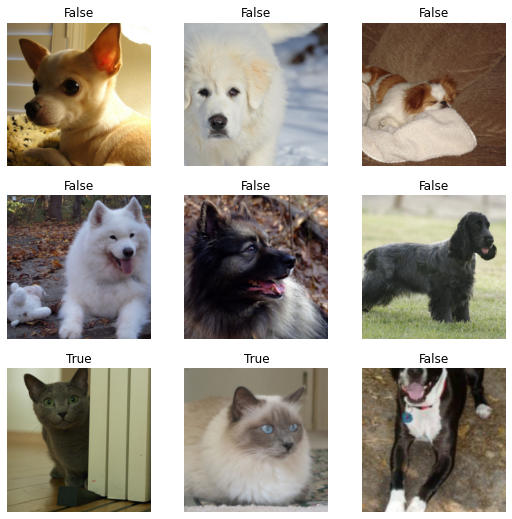

In [5]:
dls.show_batch()

Let's analyze the parameters inside the ```ImageDataLoader```:
- ```valid_pct``` is the percentage of validation set compared to training set to avoid <b>over-fitting</b>. By defaults, ```valid_pct=0.2```.
As being quoted by Jeremy <b><i>"Overfitting is the single most important and challenging issue. It is easy to create a model that does a great job at making predictions on the exact data it has been trained on, but it is much harder to make accurate predictions on data the model has never seen before." </i></b>

Afterwards, we created a ```Learner```, which provides an abstraction combining an optimizer, a model, and the data to train. THis line of code ```learn = cnn_learner(dls, resnet34, metrics= error_rate) ``` will download an ImageNet-pretrained model, if not already available, remove the classification head of the model, and set appropriate defaults for the optimizer, weight decay, learning rate and so forth. 

Basically, a ```Learner``` contains our data (i.e ```dls```), architecture (i.e. ```resnet34```) which is a mathematical function that we are optimizing and a metrics (i.e, ```error_rate```). a ```Learner``` will figure out which are the best parameters for the architecture to match the label in the dataset.

When we are talking about the metrics, which is a function that measures the quality of the model’s predictions using the validation set, it should be noted that the metrics is not necessarily the same as <b>loss</b>. The loss measures how parameters changing influences the results of performances (better or worse).  

To fits the model, the next line of code ```learn.fine_tune(1) ``` tells us how to do. Model fitting is simply looking at how many times to look at each image (```epochs```). Instead of using ```fit```, we use ```fine_tune ``` method because we started with a pre-trained model and we don' want to throw away all the capabilities that it already has. By performing  ```fine_tune ```, the parameters of a pretrained model are updated by training for additional epochs using a different task to that used for pretraining.

In sums, fine_tune is used for transfer learning, in which we used a pretrained model for a task different to what is was originally trained for.

# 2. End-to-End Digit Classifier with FastAI

## 2.1. From Data to DataLoaders

To train our model with images, the first thing we should consider is the sizes of image inputs, because we don't feed the model one image at a time but a several of them (<i>mini-batch </i>). To group them in a big array (usually called a <i>tensor </i>)) that is going to go through our
model, they all need to be of the same size. 
In FastAI, the size modification of each single image, category is done via <i>Item transform</i>), for example <i>Resize() </i> function.

The, a mini-batch of items will be ready to be fed to GPU via ```DataLoaders``` Class. By default, fastai will give us 64 items at a time, all
stacked up into a single tensor.

Instead of ```Resize```, ```RandomResizeCrop``` is also super popupar since it change how we look at the same image differently on each epoch and it is a simple technique to avoid overfitting.

### Data Augmentation

Data augmentation refers to creating random variations of our input data, such that they appear different but do not change the meaning of the data.
One of the best way to do data augmentation is to use </i> aug_transform()</i>. It will return a list of different augmentation (e.g: contrast, bright , rotation etc).

It should be noted that the data augmentation is applied into a batch of equally sized items. So, we can apply these augmentations to an entire batch of them using GPU.

# 2. Training a Digit Classifier

In this part, we will enlighten the role of

Firstly, we will download the well known MNIST dataset using fastAI

In [56]:
path = untar_data(URLs.MNIST_SAMPLE)

In [58]:
#| include: false
Path.BASE_PATH=path

In [61]:
#| include: false
path.ls()
(path/'train').ls()

(#2) [Path('train/3'),Path('train/7')]

Then, we will look at the ```train``` folder which contains image digits of '3' and '7'.

In [66]:
threes=(path/'train'/'3').ls().sorted()
sevens=(path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'),Path('train/3/10000.png'),Path('train/3/10011.png'),Path('train/3/10031.png'),Path('train/3/10034.png'),Path('train/3/10042.png'),Path('train/3/10052.png'),Path('train/3/1007.png'),Path('train/3/10074.png'),Path('train/3/10091.png')...]

Let's look at one particular handwriting image in the '7' folder

In [68]:
im7_path = sevens[1]
im7=Image.open(im7_path)
im7

To transform an image into a numeric value, we can use ```array``` method which is a part of ```Numpy array```. For instance, to show a few numbers from the image:

In [75]:
array(im7)[7:16,8:16]

array([[  0,   0,  15, 157, 254, 197,   0,   0],
       [  0,   9, 220, 254, 254, 230, 104,   0],
       [  0, 169, 254, 254, 231, 126,  40,  11],
       [183, 251, 254, 226,  81,  70, 180, 229],
       [254, 254, 255, 254, 254, 254, 255, 254],
       [254, 254, 254, 254, 253, 250, 212, 169],
       [254, 181,  77,  77,  48,   0,   0,   0],
       [195,  29,   0,   0,   0,   0,   0,  75],
       [  0,   0,   0,   0,   0,   0,  59, 217]], dtype=uint8)

In [77]:
# For Pytorch tensor
tensor(im7)[7:16,8:16]

tensor([[  0,   0,  15, 157, 254, 197,   0,   0],
        [  0,   9, 220, 254, 254, 230, 104,   0],
        [  0, 169, 254, 254, 231, 126,  40,  11],
        [183, 251, 254, 226,  81,  70, 180, 229],
        [254, 254, 255, 254, 254, 254, 255, 254],
        [254, 254, 254, 254, 253, 250, 212, 169],
        [254, 181,  77,  77,  48,   0,   0,   0],
        [195,  29,   0,   0,   0,   0,   0,  75],
        [  0,   0,   0,   0,   0,   0,  59, 217]], dtype=torch.uint8)

The beauty of using pytorch tensor over Numpy array is that the calculation of Pytorch tensor can be done in GPU.

Evenmore, we can use ```Panda``` to represent numeric values of an image because it has a very convenient thing which is so-called ```background_gradient``` that turn the background into gradient

In [79]:
im7_t = tensor(im7)
df=pd.DataFrame(im7_t[7:20,7:20])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,0,0,15,157,254,197,0,0,0,0,0,18
1,0,0,9,220,254,254,230,104,0,0,0,65,216
2,0,0,169,254,254,231,126,40,11,70,180,254,254
3,40,183,251,254,226,81,70,180,229,254,254,254,254
4,208,254,254,255,254,254,254,255,254,254,254,254,254
5,254,254,254,254,254,253,250,212,169,125,167,254,254
6,254,254,181,77,77,48,0,0,0,128,254,254,253
7,157,195,29,0,0,0,0,0,75,248,254,254,139
8,0,0,0,0,0,0,0,59,217,254,254,170,15
9,0,0,0,0,0,0,15,217,254,254,214,15,0


As we can see, the background white pixels are stored as the number zero, black is 255, and shaded grey are something in between. In MNIST dataset, an entire image contains 28 pixels across and 28 pixels down, for a total of 768 pixels. 

In the next mission, we will be going to create a model which help us to recognize '3' and '7'

First, we will create a list of all sevens and threes images by using tensor. 

In [82]:
# List comprehension in Python
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

torch.Size([28, 28])

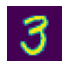

In [84]:
show_image(three_tensors[2])
three_tensors[2].shape

Then, we use Machine Learning approach that is described by Dr.Samuel to solve the differentiation problem:

</i> "Suppose we arrange for some automatic means of testing the effectiveness of any current weight assignment in terms of actual performance and provide a mechanism for altering the weight assignment so as to maximize the performance. We need not go into the details of such a procedure to see that it could be made entirely automatic and to see that a machine so programmed would “learn” from its experience." </i>

So, lets think about a function with parameter. Instead of finding an ideal image and compare every single image with an ideal image, we come up with a weight for each pixel of the image. The accumulated information of the weighted pixels gives us valuable information to differentiate between images.

To be more specific, we will build a Machine Learning classifier according to the following steps:
- Initialize the weights.
- For each image, use these weights to predict whether it appears to be a 3 or a 7.
- Based on these predictions, calculate how good the model is (its loss).
- Calculate the gradient, which measures for each weight how changing that weight would change the loss.
- Step (that is, change) all the weights based on that calculation.
- Go back to step 2 and repeat the process.
- Iterate until you decide to stop the training process (for instance, because the model is good enough or you don’t want to wait any longer).

![](ghtop_images/fastai_1/sgd.png)

### Calculate Gradients

Pytorch has a built-in engine that helps us to calculate gradient effeciently and simply. In order to do this, we start with a tensor and it comes up with a special method ```requires_grad()_```. The purpose of using this method is when we perform any calculation on a tensor, it will remember that calculation it does so that we can take the derivatives later.
Then we will call a special method ```backward``` which refers to the back propagation and do the derivative for us. 
Afterwards, we can view the gradients by checking the ```grad``` attribute of our tensor.

In [87]:
# Example
def f(x): return x**2

xt=tensor(3.).requires_grad_()
xt
yt=f(xt)
yt
yt.backward()
xt.grad

tensor(6.)

### Stepping with a learning rate

Deciding to change our parameter based on the value of the gradients is an important part. Gradient tells us the slop of a function, but does not tell us exactly how far to adjust our parameters. That'ss where the ```learning rate``` appears.

```
w -= gradient(w) * lr
```

The update of the parameters will be inversed to the gradient and is multiplied by a learning rate.
If we take a learning rate is too small, it will be needing more time for our algorithm to converge. If we take a large learning rate, it can results in the loss getting even worse. So picking up a good learning rate is really important.

Getting back to the MNIST, we need gradient to improve our model using SGD. In order to calculate gradient, we need some loss function that represent us how good our model is.

In [90]:
# Turn images and its labels into dataset
# stack the tensor together
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
# create the items and labels
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape,train_y.shape
# create dataset
dset = list(zip(train_x,train_y))

In [92]:
# repeat the same procedure for the validation set
valid_3_tens = torch.stack([tensor(Image.open(o))
for o in (path/'valid'/'3').ls()])
valid_3_tens = valid_3_tens.float()/255
valid_7_tens = torch.stack([tensor(Image.open(o))
for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255
valid_3_tens.shape,valid_7_tens.shape

valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

#### Step 1: Initialize parameter


In [93]:
def init_params(size,std=1.0): return (torch.randn(size)*std).requires_grad_()

In [96]:
weights=init_params((28*28,1))
bias = init_params(1)

We can now calculate a prediction for one image

In [97]:
(train_x[0]*weights.T).sum() + bias

tensor([-3.8565], grad_fn=<AddBackward0>)

By utilising the power of a GPU, we can predict a set of images by using matrix multiplication to loop between the pixels of an image and between images

In [98]:
def linear(xb): return xb@weights + bias
preds = linear(train_x)
preds

tensor([[-3.8565],
        [-5.0067],
        [-9.2098],
        ...,
        [-8.2678],
        [ 0.1213],
        [ 1.4608]], grad_fn=<AddBackward0>)

To check out the accuracy, to decide if an output represents a 3 or 7, we can simply apply binary method for that. if the output is greater than 0, it represent a 3 and vice versa.

In [100]:
corrects = (preds>0.0).float() == train_y
corrects

tensor([[False],
        [False],
        [False],
        ...,
        [ True],
        [False],
        [False]])

In [104]:
#| include: false
corrects.float().mean().item()

0.3957728445529938

Notice that we can not apply the accuracy for the loss function here because a small changes of paramters does not lead to the significant changes of the results, so we need to build a new loss function to estimate the prediction.
The following function will give a first try of measuring the distance between predictions and targets:

In [106]:
def mnist_loss(predictions,targets):
    return torch.where(targets==1,1-predictions,predictions).mean()

One problem with mnist_loss is that it assumes the predictions are always between 0 and 1. Then, we need to ensure that it is always the case. That's the place for the activation function - Sigmoid function

#### Sigmoid

In [107]:
def sigmoid(x): return 1/(1+torch.exp(-x))

/home/tmpext4/nd258645/conda-env/lib/python3.8/site-packages/fastbook/__init__.py:74: UserWarning: Not providing a value for linspace's steps is deprecated and will throw a runtime error in a future release. This warning will appear only once per process. (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448278899/work/aten/src/ATen/native/RangeFactories.cpp:25.)
  x = torch.linspace(min,max)


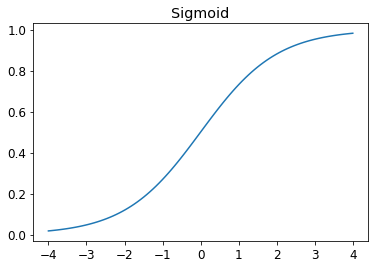

In [108]:
plot_function(torch.sigmoid, title='Sigmoid',min=-4,max=4)

Then, let's update mnist_loss with sigmoid function:

In [109]:
def mnist_loss(predictions,targets):
    predictions=predictions.sigmoid()
    return torch.where(targets==1,1-predictions,predictions).mean()

#### SGD and mini-batches
In order to change or update the weight, we will walk through the ```step``` method (optimisation step). To take an optimiser step we need to calculate the loss over one or more data items. If we perform the optimisation step for every single item, it would take a very long time. On the other hand, if we perform the step for the whole data set at once, it could return an unstable gradient.

So, we will take a compromise between the two: we calculate the average loss for a few data items at a time(<i>mini-batches</i>). The number of data items in a batch is call <i>batch size </i>. A larger batch size means you will get more accurate and stable estimation of our dataset's gradienton the loss function, but it will take longer and you will get less mini-batches per epoch. Then, choosing a good batch size is one of the decision that is to help deep learning to train our model quickly and accurately.



In Pytorch and fastAI, there is a class that will do the shuffling and minibatch collation for us, called ```DataLoader```

In [110]:
# example
coll = range(15)
dl = DataLoader(coll,batch_size=5,shuffle=True)
list(dl)

[tensor([ 3, 12,  8, 10,  2]),
 tensor([ 9,  4,  7, 14,  5]),
 tensor([ 1, 13,  0,  6, 11])]

In [113]:
# Back to the MNISN
dl = DataLoader(dset,batch_size=256)
valid_dl = DataLoader(valid_dset,batch_size=256)
# 
def calc_grad(xb,yb,model):
    preds=model(xb)
    loss=mnist_loss(preds,yb)
    loss.backward()
    
batch=train_x[:4]
calc_grad(batch,train_y[:4],linear)
weights.grad.mean(),bias.grad

(tensor(-0.0029), tensor([-0.0204]))

In [114]:
calc_grad(batch,train_y[:4],linear)
weights.grad.mean(),bias.grad

(tensor(-0.0039), tensor([-0.0272]))

When we will perform the ```calc_grad``` twice, although we have not changed anything related to the weights, but the gradient results return different values!!! 
The reason for that is that ```loss.backward``` actually adds the gradients of loss into any gradients that are currently stored. So we have to set the current gradients to zero first.

In [115]:
weights.grad.zero_()
bias.grad.zero_();

Then, we will update the weights and bias based on the gradient and learning rate. 

In [119]:
def train_epoch(model,lr,params):
    for xb,yb in dl:
        calc_grad(xb,yb,model)
        for p in params:
                p.data -= p.grad*lr
                p.grad.zero_()

In [121]:
# Let's look at the accuracy of the validation set
(preds>0.0).float() == train_y

tensor([[False],
        [False],
        [False],
        ...,
        [ True],
        [False],
        [False]])

Then, we calculate the accuracy

In [125]:
def batch_accuracy(xb,yb):
    preds = xb.sigmoid()
    corrects=(preds>0.5)==yb
    return corrects.float().mean()

In [126]:
batch_accuracy(linear(batch),train_y[:4])

tensor(0.)

In [129]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb),yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(),4)

In [130]:
validate_epoch(linear)

0.4085

Let's train in one epoch

In [131]:
lr = 1.
params=weights,bias
train_epoch(linear,lr,params)
validate_epoch(linear)

0.5849

In [133]:
for i in range(20):
    train_epoch(linear,lr,params)
    print(validate_epoch(linear),end=' ')

0.973 0.973 0.9735 0.9745 0.9749 0.9754 0.9759 0.9759 0.9759 0.9764 0.9774 0.9779 0.9779 0.9784 0.9784 0.9784 0.9789 0.9794 0.9794 0.9794 

So, we have succesfully built a SGD optimizer of a simple linear function anf get the accuracy upto 97.94%

#### Creating an optimizer

In order to automate the initialization of an optimizer, Pytorch provides some useful functions to replace our ```linear()``` function with Pytorch's ```nn.Linear``` module.

```nn.Linear``` does the same thing as our ```init_params``` and ```Linear``` together. It contains both weights and bias in a single class.

In [138]:
linear_model = nn.Linear(28*28,1)
w,b = linear_model.parameters()
w.shape,b.shape

(torch.Size([1, 784]), torch.Size([1]))

The, we can use this information to create an optimizer:

In [140]:
class BasicOptim:
    def __init__(self,params,lr): self.params, self.lr= list(params),lr
        
    def step(self,*args,**kwargs):
        for p in self.params: 
            p.data-= p.grad.data*self.lr
    
    def zero_grad(self,*args,**kwargs):
        for p in self.params:
            p.grad=None
            

In [142]:
opt = BasicOptim(linear_model.parameters(),lr)

Then, the new training loop should be:

In [145]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb,yb,model)
        opt.step()
        opt.zero_grad()

def train_model(model,epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [146]:
train_model(linear_model,30)

0.4932 0.8076 0.8554 0.917 0.935 0.9487 0.9575 0.9633 0.9653 0.9677 0.9697 0.9716 0.9736 0.9751 0.976 0.9765 0.9775 0.9775 0.9785 0.9785 0.979 0.979 0.979 0.979 0.9795 0.9795 0.9799 0.9804 0.9809 0.9814 

In FastAI, it provides us an API of ```SGD``` class which does the same thing as ```BasicOptim```

In [147]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(),lr)

train_model(linear_model,30)

0.4932 0.789 0.853 0.9155 0.935 0.9492 0.9555 0.9638 0.9658 0.9672 0.9697 0.9716 0.9731 0.9751 0.9755 0.977 0.9775 0.978 0.978 0.9785 0.979 0.979 0.979 0.9795 0.9795 0.9795 0.9799 0.9804 0.9804 0.9814 

FastAI also provides ```Learner.fit```, which we can use instead of ```train_model```. To create a ```Learner``` we first need to create ```DataLoader```, by passing in our training and validation DataLoaders.

In [148]:
dls=DataLoaders(dl,valid_dl)

In [149]:
learn=Learner(dls,nn.Linear(28*28,1),opt_func=SGD,loss_func=mnist_loss,metrics=batch_accuracy)

In [152]:
learn.fit(10,lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.009775,0.017821,0.985280,00:00
1,0.009761,0.017807,0.985280,00:00
2,0.009744,0.017793,0.985280,00:00
3,0.009726,0.017780,0.985280,00:00
4,0.009707,0.017767,0.985280,00:00
5,0.009688,0.017754,0.985280,00:00
6,0.009669,0.017742,0.985280,00:00
7,0.009650,0.017730,0.985280,00:00
8,0.009631,0.017717,0.985280,00:00
9,0.009613,0.017706,0.985280,00:00


### Adding a non-linearity

So far, we studied a general procedure for optimising the parameters of a function by using a simple linear classifier. To make it a bit more sophisticated, we need to add a non-linearity between two linear classifiers, and this gives us a neural network

In [153]:
#Example of a simple neural net
def simple_net(xb):
    s1=xb@w1+b1
    res=s1.max(tensor(0.0))
    s2=res@w2+b2
    return s2
    

The little ```s1.max(tensor(0.0))``` is called <i> rectified linear unit (RELU)</i>. In Pytorch, it is also available as ```F.relu``` 

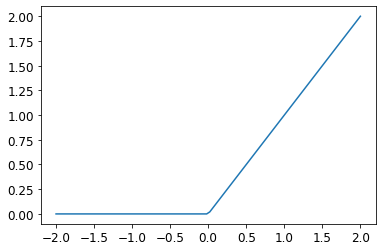

In [154]:
plot_function(F.relu)

The addition of nonlinear function, we can provide what ```Universal Approximation Theorem``` says, which can represent any arbitrary function.

We can replace the initialization of the basic neural network by taking advantage of Pytorch:

In [160]:
simple_net = nn.Sequential(
nn.Linear(28*28,30),
nn.ReLU(),
nn.Linear(30,1)
)

```nn.Sequential``` is a module that calls each of the listed layers or function in turn.

In [161]:
learn=Learner(dls,simple_net,opt_func=SGD,loss_func=mnist_loss,metrics=batch_accuracy)
#| output: false
learn.fit(40,0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.300018,0.414335,0.504907,00:00
1,0.141675,0.223938,0.810599,00:00
2,0.078998,0.113296,0.920020,00:00
3,0.052353,0.076984,0.939647,00:00
4,0.039966,0.060442,0.956820,00:00
5,0.033602,0.051149,0.963199,00:00
6,0.029922,0.045272,0.965653,00:00
7,0.027511,0.041248,0.967615,00:00
8,0.025765,0.038313,0.968597,00:00
9,0.024406,0.036064,0.970069,00:00


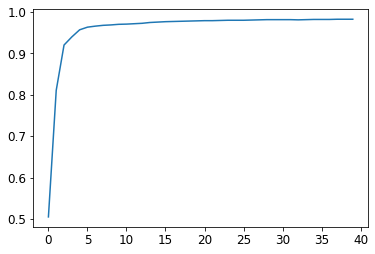

In [162]:
plt.plot(L(learn.recorder.values).itemgot(2))

For deeper models, we may need to use a lower learning rate and a few more epochs.
In practice, we can freely to set many layers as well as the nonlinearity between layers. However, the deeper the model gets, the  harder it is to optimize the parameters in practice. So why we would use a deeper model? The reason is the performance. With the deeper model, it turns out that we can use smaller matrices , with more layers, and get better results that we would get with larger matrices and few layers.

Here is what happens when we train an 18-layer model

In [164]:
dls=ImageDataLoaders.from_folder(path)
learn=cnn_learner(dls,resnet18,pretrained=False, loss_func=F.cross_entropy, metrics=accuracy)

learn.fit_one_cycle(1,0.1)

/home/tmpext4/nd258645/conda-env/lib/python3.8/site-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448278899/work/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


epoch,train_loss,valid_loss,accuracy,time
0,0.156772,0.021748,0.995584,00:32
